# 컴퓨터 비전

### 담당교수 : 장원중

#### 그래프 한글이 깨질때 & 마이너스 부호 사용

In [1]:
import sys, os
from matplotlib import font_manager, rc 
import matplotlib.pyplot as plt

# 한글 폰트 설정 : 윈도우 폰트를 사용하는 경우 
# font_name = font_manager.FontProperties(fname="c:/Windows/Fonts/malgun.ttf").get_name()
# rc('font', family=font_name) 

# 운영체제별 한글 폰트 설정
if os.name == 'posix': # Mac 환경 폰트 설정
    rc('font', family='AppleGothic')
elif os.name == 'nt': # Windows 환경 폰트 설정
    rc('font', family='Malgun Gothic')

plt.rc('axes', unicode_minus=False) # 마이너스 폰트 설정

# 유니코드에서 음수 부호설정
rc('axes', unicode_minus=False)

# 부모 디렉터리의 파일을 가져올 수 있도록 설정
sys.path.append(os.pardir)     

# jupyter에서 matplotlib 그래프를 출력 영역에 표시  
%matplotlib inline 

# 레티나 설정 - 폰트 주변이 흐릿하게 보이는 것을 방지해 글씨가 좀 더 선명하게 보임
%config InlineBackend.figure_format = 'retina'

In [2]:
# 운영체제별 이름 

import platform

platform.system()

'Windows'

# 텐스플로 완전연결층 프로그래밍(4층)

### 패션 MNIST 데이터 읽어오기 

In [3]:
# tensorflow와 tensorflow.keras를 모듈 읽어오기 

import tensorflow as tf
from tensorflow import keras 
import numpy as np
import matplotlib.pyplot as plt

In [4]:
# 패션 MNIST 데이터는 keras의 데이터셋에 있는데 이를 읽어와서 학습용, 테스트 데이터로 구분한다.
fashion_mnist = keras.datasets.fashion_mnist 
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

print(train_images.shape)  # 학습 이미지의 형상 : (60000, 28, 28)
print(train_labels)        # 학습 이미지의 레이블 : [9 0 0 ... 3 0 5] 
print(test_images.shape)   # 테스트 이미지의 형상 : (10000, 28, 28)

(60000, 28, 28)
[9 0 0 ... 3 0 5]
(10000, 28, 28)


## 인공신경망 계층구조를 2층으로 학습하기

In [5]:
# 2층 신경망 계층구조 
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

# 신경망 학습 
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

hist = model.fit(train_images, train_labels, epochs=30)

Epoch 1/30
1875/1875 [==============================] - 5s 2ms/step - loss: 3.4334 - accuracy: 0.6734
Epoch 2/30
1875/1875 [==============================] - 4s 2ms/step - loss: 0.7216 - accuracy: 0.7278
Epoch 3/30
1875/1875 [==============================] - 4s 2ms/step - loss: 0.5954 - accuracy: 0.7844
Epoch 4/30
1875/1875 [==============================] - 4s 2ms/step - loss: 0.5561 - accuracy: 0.8073
Epoch 5/30
1875/1875 [==============================] - 4s 2ms/step - loss: 0.5313 - accuracy: 0.8158
Epoch 6/30
1875/1875 [==============================] - 4s 2ms/step - loss: 0.5096 - accuracy: 0.8273
Epoch 7/30
1875/1875 [==============================] - 4s 2ms/step - loss: 0.4960 - accuracy: 0.8295
Epoch 8/30
1875/1875 [==============================] - 4s 2ms/step - loss: 0.4839 - accuracy: 0.8328
Epoch 9/30
1875/1875 [==============================] - 4s 2ms/step - loss: 0.4889 - accuracy: 0.8326
Epoch 10/30
1875/1875 [==============================] - 4s 2ms/step - loss: 0.472

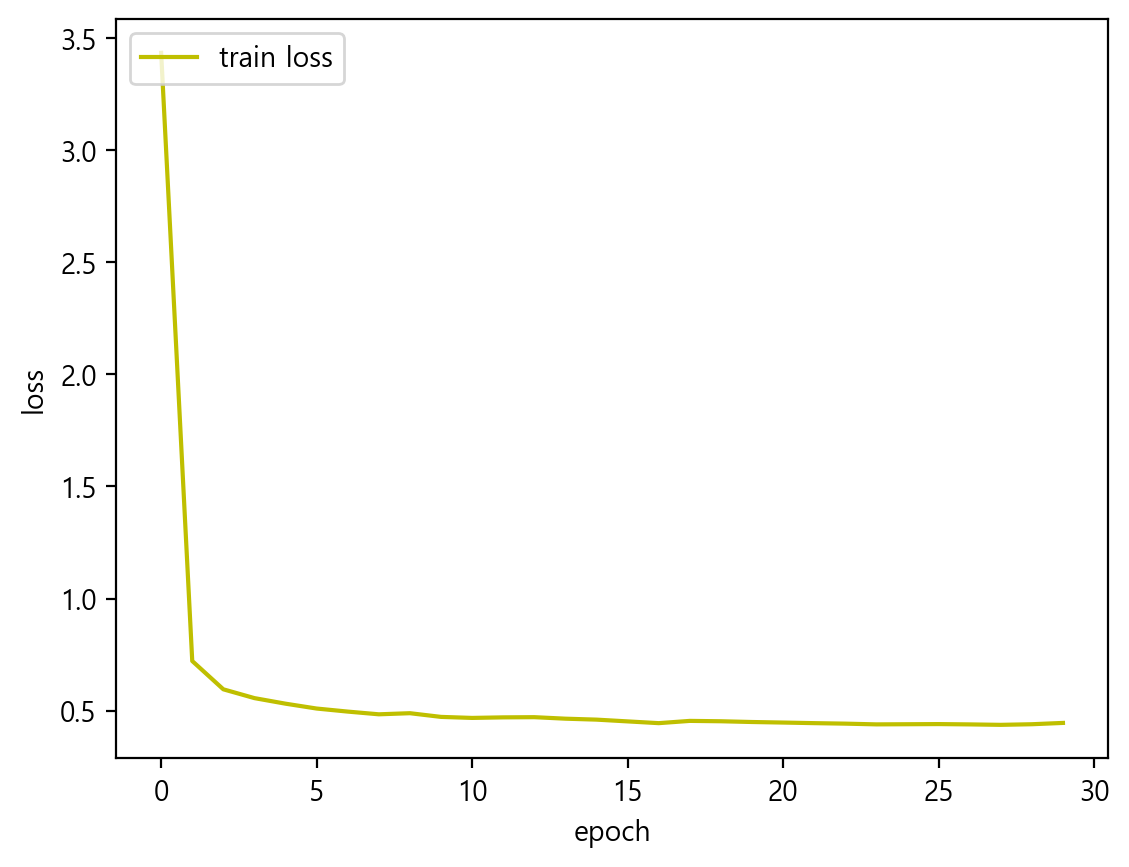

In [6]:
# 학습결과 시각화하기   

import matplotlib.pyplot as plt

fig, loss_ax = plt.subplots()

loss_ax.plot(hist.history['loss'], 'y', label='train loss')
loss_ax.set_xlabel('epoch')
loss_ax.set_ylabel('loss')
loss_ax.legend(loc='upper left')

plt.show()

## 인공신경망 계층구조를 4층으로 확장하여 학습하기

In [7]:
# 인공신경망 계층구조 구축
#  - 텐스플로(케라스)의 Dense는 학습을 위한 연결을 밀집된(dense) 구조 혹은 완전연결(Fully connected) 층으로 한다. 

# 4개의 층을 가진 네트워크 모델 생성 
#  - Flatten 계층 : 입력 (28, 28) 
#  - Dense 네트워크 : 출력 128, ReLU 활성화함수 
#  - Dense 네트워크 : 출력 64, ReLU 활성화함수 
#  - Dense 네트워크 : 출력 32, ReLU 활성화함수 
#  - Dense 네트워크 : 출력 10, SoftMax 활성화함수
model2 = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

# 신경망 학습 
#  - 최적화(optimization) 기법 : 아담(adam) 
#  - 손실함수 : sparse_categorical_crossentropy 
#  - 모델 평가 : 정확도(accuracy)
model2.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# 신경망 학습 
#  - 반복 횟수 : 30개의 에폭(epoch)
hist2 = model2.fit(train_images, train_labels, epochs=30)

Epoch 1/30
1875/1875 [==============================] - 5s 2ms/step - loss: 1.4944 - accuracy: 0.5177
Epoch 2/30
1875/1875 [==============================] - 4s 2ms/step - loss: 0.7499 - accuracy: 0.7139
Epoch 3/30
1875/1875 [==============================] - 4s 2ms/step - loss: 0.6214 - accuracy: 0.7431
Epoch 4/30
1875/1875 [==============================] - 4s 2ms/step - loss: 0.5628 - accuracy: 0.7685
Epoch 5/30
1875/1875 [==============================] - 4s 2ms/step - loss: 0.4989 - accuracy: 0.8156
Epoch 6/30
1875/1875 [==============================] - 4s 2ms/step - loss: 0.4329 - accuracy: 0.8504
Epoch 7/30
1875/1875 [==============================] - 4s 2ms/step - loss: 0.4002 - accuracy: 0.8589
Epoch 8/30
1875/1875 [==============================] - 4s 2ms/step - loss: 0.3694 - accuracy: 0.8667
Epoch 9/30
1875/1875 [==============================] - 4s 2ms/step - loss: 0.3559 - accuracy: 0.8723
Epoch 10/30
1875/1875 [==============================] - 4s 2ms/step - loss: 0.344

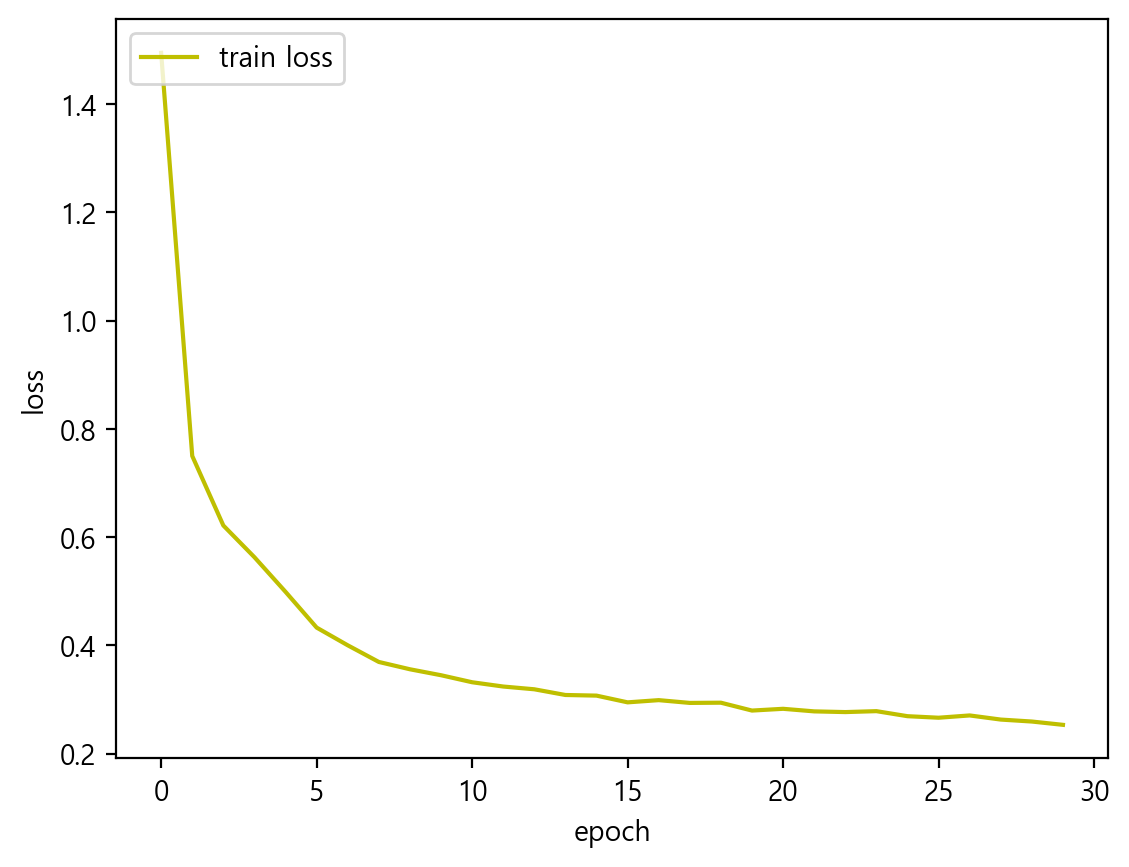

In [8]:
# 학습결과 시각화하기

import matplotlib.pyplot as plt

fig, loss_ax = plt.subplots()

loss_ax.plot(hist2.history['loss'], 'y', label='train loss')
loss_ax.set_xlabel('epoch')
loss_ax.set_ylabel('loss')
loss_ax.legend(loc='upper left')

plt.show()

In [9]:
# 테스트 데이터를 이용한 모델 평가 

test_loss, test_acc = model2.evaluate(test_images, test_labels, verbose=2)

print('\n테스트 정확도:', test_acc)   # 테스트 정확도: 0.8640000224113464

313/313 - 1s - loss: 0.3960 - accuracy: 0.8773 - 759ms/epoch - 2ms/step

테스트 정확도: 0.8773000240325928


## 층을 쌓아 얼마나 좋아졌는지 눈으로 확인하기 : 2층과 4층 비교 

In [10]:
# 2층 신경망 model과 4층 신경망 model2를 이용하여 테스트 이미지로 예측하기 

pred1 = model.predict(test_images)    # model 예측  
pred2 = model2.predict(test_images)   # model2 예측 

y_hat1 = np.argmax(pred1, axis=1)     # model 예측 
y_hat2 = np.argmax(pred2, axis=1)     # model2 예측  

313/313 [==============================] - 1s 2ms/step


[[749   5  69  25   2   3 134   0  13   0]
 [  3 961  10  21   2   0   1   0   2   0]
 [  8   1 764   4 128   0  87   0   8   0]
 [ 28  13  75 786  13   0  75   1   9   0]
 [  0   1 133  46 717   0  95   0   8   0]
 [  1   0   7   0   0 920   1  39   7  25]
 [104   0 193  21 154   0 458   0  70   0]
 [  0   0   0   0   0  14   0 964   1  21]
 [  0   0   9   3   1   3  21   5 958   0]
 [  0   0   0   0   0   7   1  48   0 944]]
[[856   2  21  16   3   3  93   0   6   0]
 [  6 972   1  16   1   0   3   0   1   0]
 [ 14   1 768  13 131   0  72   0   1   0]
 [ 29   7  13 885  25   0  39   0   2   0]
 [  0   0  74  49 801   1  72   0   3   0]
 [  0   0   1   0   0 964   0  25   0  10]
 [155   2  89  21  74   0 650   0   9   0]
 [  0   0   0   0   0   5   0 985   0  10]
 [  1   0   5   5   3   2  22   3 959   0]
 [  0   0   0   0   1   9   0  56   1 933]]


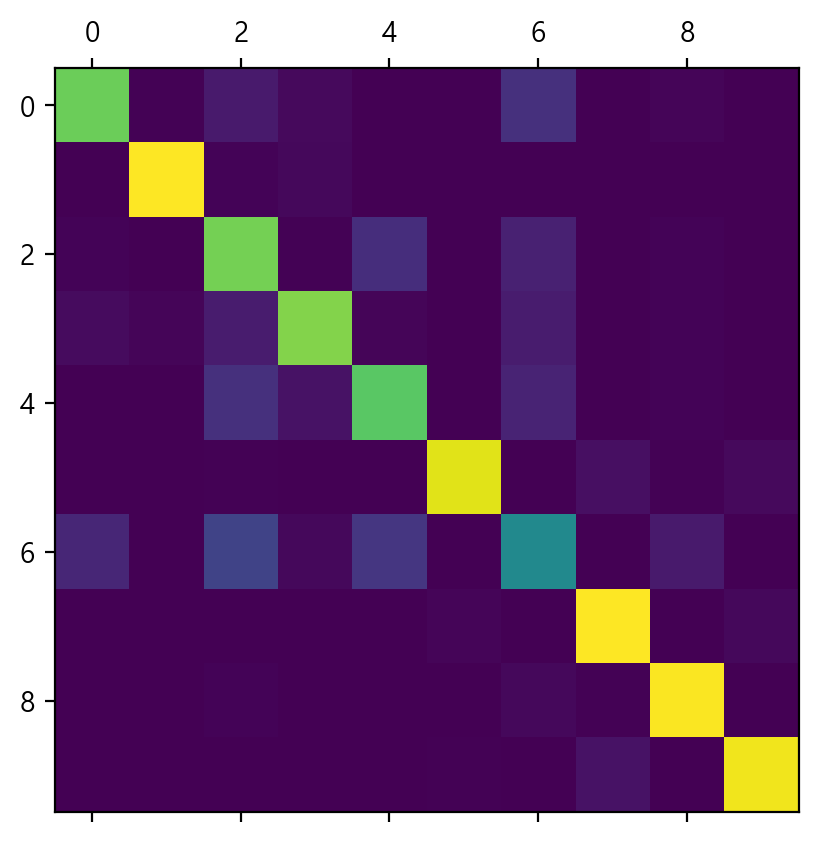

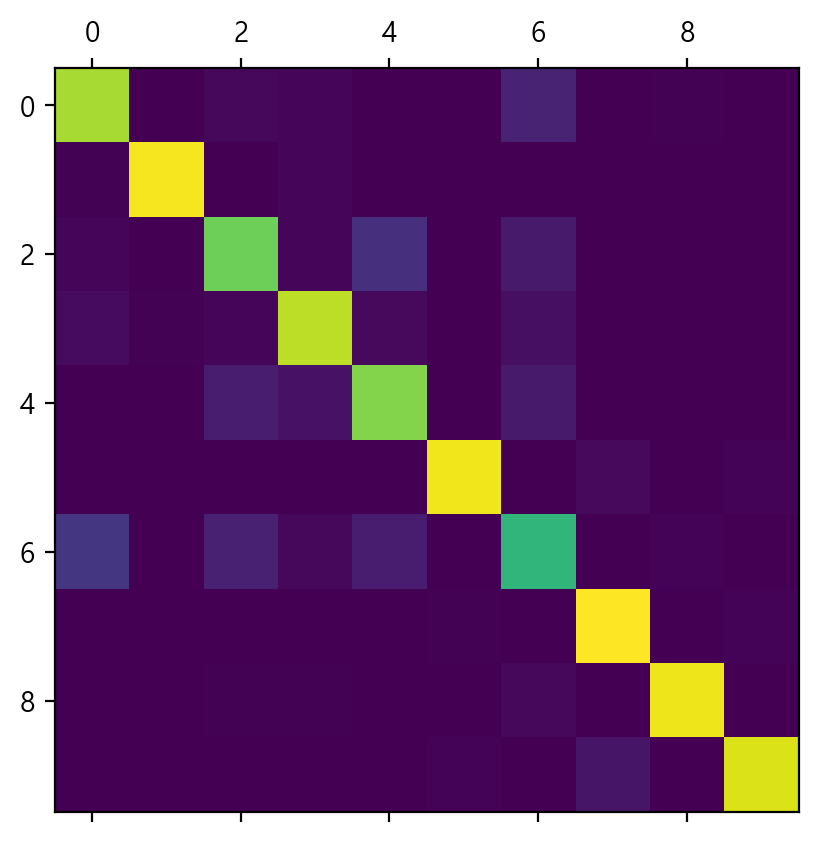

In [11]:
# 혼동행렬을 이용하여 모델의 예측값 실제값을 비교해 보자. 

from sklearn.metrics import confusion_matrix 

matrix1 = confusion_matrix(test_labels, y_hat1)
matrix2 = confusion_matrix(test_labels, y_hat2)

print(matrix1)
print(matrix2)

plt.matshow(matrix1)
plt.matshow(matrix2)

# 실행 결과 
#  - 층을 더 쌓아 학습을 시켰을 때에 눈에 띄는 변화는 클래스 4의 인식을 제대로 하는 경우가 대폭 늘어난 것이다. 
#  - 또한, 클래스 6에 속하지 않는 이미지를 6으로 잘못 분류한 경우가 줄었다. 
#  - 층을 쌓음으로써 모델의 학습이 더 잘 된 것을 확인할 수 있다.  

### 은닉층을 쌓기만 하면 좋은 모델이 될까 !!!

In [ ]:
# 앞의 예에서 층을 쌓아나감으로써 단순한 모델에 비해 더 좋은 학습 능력을 갖추기도 했지만, 동시에 여러 문제가 발생하게 된다. 

# (1) 대표적인 문제는 모델이 복잡해서 계산 시간이 많이 소요된다는 것이다. 
#     - 더 중요한 문제는 단순한 구조로 층만 깊이 쌓을 경우, 
#       출력 부분의 잘못에 근거한 학습의 내용이 입력에 가까운 네트워크 층까지 전파가 잘 되지 않는다는 것이다.
#     - 따라서, 층이 깊어질수록 입력에 따라 다른 동작을 내도록 조장하기 어려워진다는 문제도 발견되었다. 
#     - 이것은 층을 높이 쌓을수록 학습이 제대로 되지 않는다는 것이다. 
#     - 이러한 이유로 심층 구조는 학습이 이루어진다 해고 과적합이 되는 특성을 갖는다.  

# 다양한 방법으로 깊은 구조를 가진 신경망을 학습시키는 방법을 오랫동안 연구되었다. 
#  - 그 대표적인 연구자가 제프리 힌튼 교수이다. 
#  - 제프리 힌튼(Geoffrey Hinton), 요수아 벤지오(Yoshua Bengio), 얀 르쿤(Yann LeCun) 등이 합성곱 신경망(CNN) 모델을 만들어 냄으로써 
#    심층 신경망을 효과적으로 학습시킬 수 있는 돌파구를 보여주었다. 

### 학습된 모델 (4층 신경망) 저장하고 불러와서 사용하기

In [12]:
# 학습된 모델 저장하기 

import os

model2.save(os.getcwd()+'/model/fashion_dnn4_model.h5')
print("Saved model to disk !!!")

Saved model to disk !!!


In [13]:
# 필요한 패키지와 모듈을 불러오기 

import os
from tensorflow.keras.models import load_model

model2 = load_model(os.getcwd()+'/model/fashion_dnn4_model.h5')
model2.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_1 (Flatten)         (None, 784)               0         
                                                                 
 dense_2 (Dense)             (None, 128)               100480    
                                                                 
 dense_3 (Dense)             (None, 64)                8256      
                                                                 
 dense_4 (Dense)             (None, 32)                2080      
                                                                 
 dense_5 (Dense)             (None, 10)                330       
                                                                 
Total params: 111,146
Trainable params: 111,146
Non-trainable params: 0
_________________________________________________________________


(596, 576)


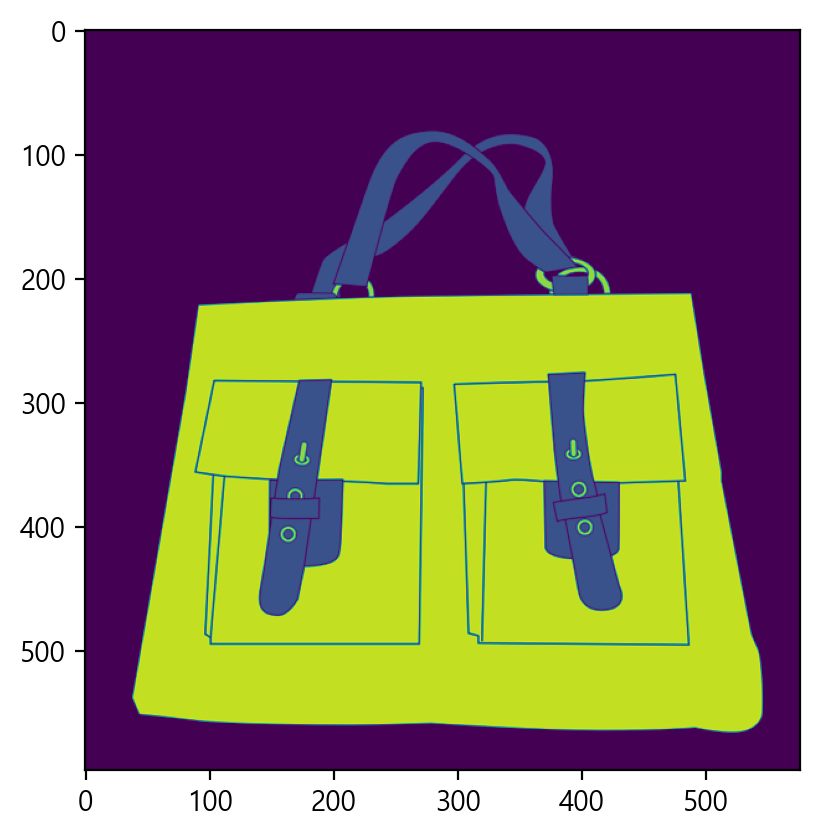

In [14]:
# 만화같은 가방 이미지 회색조로 읽어오기 

import cv2
import os

img2 = cv2.imread(os.getcwd()+'/images/bag_cartoon.png', cv2.IMREAD_GRAYSCALE)
plt.imshow(img2)
print(img2.shape)                  # 형상 (596, 576)

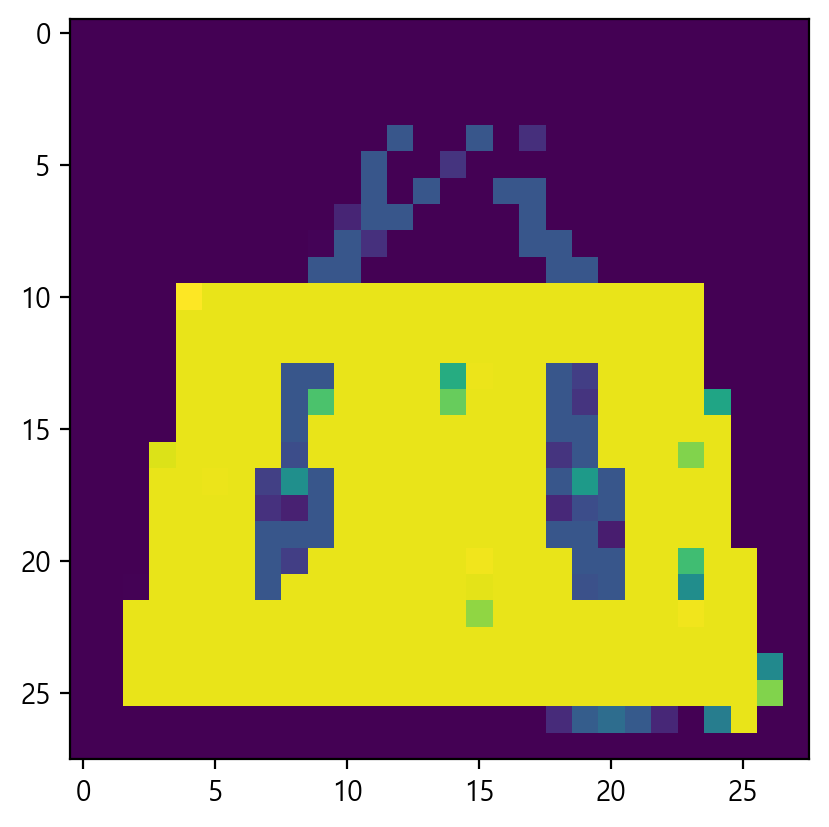

In [15]:
# 만화같은 가방 이미지 형상 변경하기 

img2 = cv2.resize(img2, (28, 28))
plt.imshow(img2)

In [20]:
# 클래스 이름을 리스트로 만들기 
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'] 

# 만화같은 가방 이미지 형상을 3차원으로 늘려서 모델에 입력 
input_data2 = img2[np.newaxis, :, :]
yhat2 = np.argmax(model2.predict(input_data2))    # 저장된 모델에 만화같은 가방 이미지 인식하기 

print(class_names[yhat2])    # Bag

1/1 [==============================] - 0s 16ms/step
Bag


## 인공신경망 계층구조를 5층으로 확장하여 학습하기

In [22]:
# 인공신경망 계층구조 구축
#  - 텐스플로(케라스)의 Dense는 학습을 위한 연결을 밀집된(dense) 구조 혹은 완전연결(Fully connected) 층으로 한다. 

# 4개의 층을 가진 네트워크 모델 생성 
#  - Flatten 계층 : 입력 (28, 28) 
#  - Dense 네트워크 : 출력 128, ReLU 활성화함수 
#  - Dense 네트워크 : 출력 64, ReLU 활성화함수 
#  - Dense 네트워크 : 출력 32, ReLU 활성화함수 
#  - Dense 네트워크 : 출력 10, SoftMax 활성화함수
model3 = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(256, activation='relu'),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

# 신경망 학습 
#  - 최적화(optimization) 기법 : 아담(adam) 
#  - 손실함수 : sparse_categorical_crossentropy 
#  - 모델 평가 : 정확도(accuracy)
model3.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# 신경망 학습 
#  - 반복 횟수 : 30개의 에폭(epoch)
hist3 = model3.fit(train_images, train_labels, epochs=30)

Epoch 1/30
1875/1875 [==============================] - 10s 5ms/step - loss: 0.9880 - accuracy: 0.7167
Epoch 2/30
1875/1875 [==============================] - 10s 5ms/step - loss: 0.5161 - accuracy: 0.8120
Epoch 3/30
1875/1875 [==============================] - 10s 5ms/step - loss: 0.4359 - accuracy: 0.8437
Epoch 4/30
1875/1875 [==============================] - 11s 6ms/step - loss: 0.3995 - accuracy: 0.8580
Epoch 5/30
1875/1875 [==============================] - 11s 6ms/step - loss: 0.3757 - accuracy: 0.8654
Epoch 6/30
1875/1875 [==============================] - 10s 5ms/step - loss: 0.3540 - accuracy: 0.8711
Epoch 7/30
1875/1875 [==============================] - 9s 5ms/step - loss: 0.3424 - accuracy: 0.8765
Epoch 8/30
1875/1875 [==============================] - 10s 5ms/step - loss: 0.3305 - accuracy: 0.8808
Epoch 9/30
1875/1875 [==============================] - 10s 5ms/step - loss: 0.3194 - accuracy: 0.8862
Epoch 10/30
1875/1875 [==============================] - 10s 5ms/step - lo

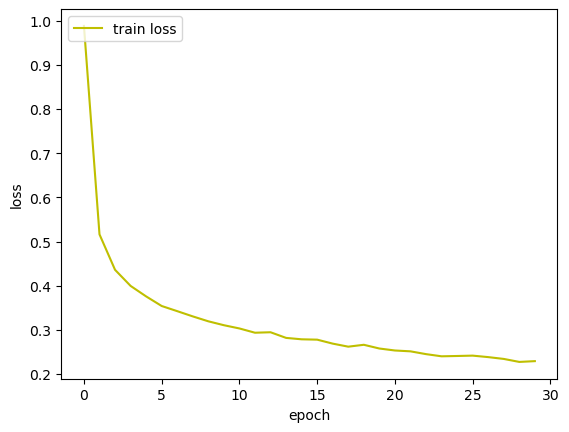

In [23]:
# 학습과정 표시하기 
import matplotlib.pyplot as plt

fig, loss_ax = plt.subplots()

loss_ax.plot(hist3.history['loss'], 'y', label='train loss')
loss_ax.set_xlabel('epoch')
loss_ax.set_ylabel('loss')
loss_ax.legend(loc='upper left')

plt.show()

In [24]:
# 테스트 데이터를 이용한 모델 평가 

test_loss, test_acc = model3.evaluate(test_images, test_labels, verbose=2)

print('\n테스트 정확도:', test_acc)   # 테스트 정확도: 0.8852999806404114

313/313 - 1s - loss: 0.4039 - accuracy: 0.8853 - 704ms/epoch - 2ms/step

테스트 정확도: 0.8852999806404114


In [25]:
# 2층 신경망 model과 4층 신경망 model2를 이용하여 테스트 이미지로 예측하기 

pred1 = model2.predict(test_images)    # model 예측  
pred2 = model3.predict(test_images)   # model2 예측 

y_hat1 = np.argmax(pred1, axis=1)     # model 예측 
y_hat2 = np.argmax(pred2, axis=1)     # model2 예측  

313/313 [==============================] - 1s 2ms/step


[[903   1  19  29   4   0  36   0   8   0]
 [  9 965   2  19   3   0   2   0   0   0]
 [ 28   5 843  12  80   0  31   0   1   0]
 [ 31   7  11 898  35   0  14   0   4   0]
 [  1   0 128  34 808   0  29   0   0   0]
 [  0   0   0   0   0 954   0  27   5  14]
 [245   0 130  37  97   0 489   0   2   0]
 [  0   0   0   0   0  20   0 967   0  13]
 [ 19   1   1   7   4   1  14   4 949   0]
 [  0   0   0   1   0  15   1  66   0 917]]
[[844   3  28  32   5   0  85   0   3   0]
 [  0 972   2  21   3   0   1   0   1   0]
 [ 10   1 836  14  94   0  45   0   0   0]
 [ 23   8  14 894  38   1  19   0   3   0]
 [  1   0 107  26 827   0  39   0   0   0]
 [  0   0   0   1   0 950   0  27   1  21]
 [128   1 105  35  76   0 649   0   6   0]
 [  0   0   0   0   0  18   0 944   0  38]
 [  5   0   3   2   9   2   7   4 968   0]
 [  0   0   0   0   0   3   1  27   0 969]]


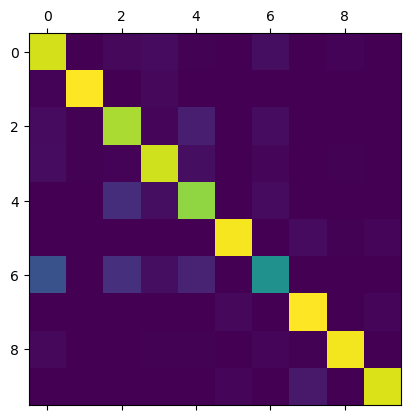

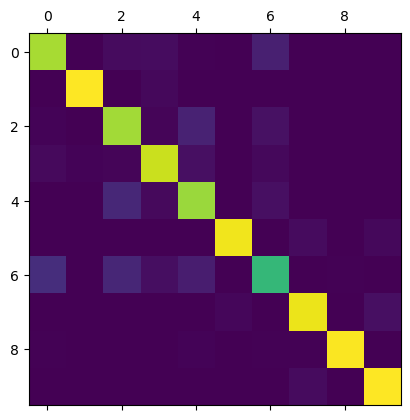

In [26]:
# 혼동행렬을 이용하여 모델의 예측값 실제값을 비교해 보자. 

from sklearn.metrics import confusion_matrix 

matrix1 = confusion_matrix(test_labels, y_hat1)
matrix2 = confusion_matrix(test_labels, y_hat2)

print(matrix1)
print(matrix2)

plt.matshow(matrix1)
plt.matshow(matrix2)